In [2]:
import pandas as pd
# importing pandas for creating dataframe
import numpy as np
# importing numpy for mathematical operations
import matplotlib.pyplot as plt
# import matplotlib.pyplot for visualizations

In [3]:
from sklearn.model_selection import train_test_split
# importing train_test_split for training and testing
from sklearn.linear_model import LinearRegression
# importing LinearRegression model for analysing and predicting
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
# importing metrics of linear regression for evaluating model performance

In [5]:
data = {
    "Study_Hours":[1,2,3,4,5,6,7,8,9,10,11,12],
    "Attendance":[60,65,70,72,75,80,82,85,88,90,92,95],
    "Assignments":[2,3,4,5,5,6,7,7,8,8,9,10],
    "Marks":[35,40,45,50,58,65,72,78,82,88,92,96]
}
df=pd.DataFrame(data)
#converting the data into a dataframe(table)
print(df)
df.to_csv("student_performance.csv", index=False)
# converting into .csv file
print("csv saved successfully")

csv saved successfully


 Dataset Exploration

In [6]:
print("First 5 rows of all columns")
print(df.head())

First 5 rows of all columns
   Study_Hours  Attendance  Assignments  Marks
0            1          60            2     35
1            2          65            3     40
2            3          70            4     45
3            4          72            5     50
4            5          75            5     58


In [7]:
print("Last 5 rows of all columns")
print(df.tail())

Last 5 rows of all columns
    Study_Hours  Attendance  Assignments  Marks
7             8          85            7     78
8             9          88            8     82
9            10          90            8     88
10           11          92            9     92
11           12          95           10     96


In [8]:
print("Dataset shape")
print(df.shape)

Dataset shape
(12, 4)


In [9]:
print("Displaying column names")
print(df.columns)

Displaying column names
Index(['Study_Hours', 'Attendance', 'Assignments', 'Marks'], dtype='object')


In [12]:
print("Displaying datatypes")
print(df.info())

Displaying datatypes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  12 non-null     int64
 1   Attendance   12 non-null     int64
 2   Assignments  12 non-null     int64
 3   Marks        12 non-null     int64
dtypes: int64(4)
memory usage: 516.0 bytes
None


In [13]:
print("Statistical summery of dataset")
print(df.describe())

Statistical summery of dataset
       Study_Hours  Attendance  Assignments      Marks
count    12.000000   12.000000    12.000000  12.000000
mean      6.500000   79.500000     6.166667  66.750000
std       3.605551   11.172206     2.443296  21.080474
min       1.000000   60.000000     2.000000  35.000000
25%       3.750000   71.500000     4.750000  48.750000
50%       6.500000   81.000000     6.500000  68.500000
75%       9.250000   88.500000     8.000000  83.500000
max      12.000000   95.000000    10.000000  96.000000


Features and Label

In [16]:
# input features
X=df[['Study_Hours','Attendance','Assignments']]
# target variable or label or output
Y=df['Marks']
print(X)
print(Y)

    Study_Hours  Attendance  Assignments
0             1          60            2
1             2          65            3
2             3          70            4
3             4          72            5
4             5          75            5
5             6          80            6
6             7          82            7
7             8          85            7
8             9          88            8
9            10          90            8
10           11          92            9
11           12          95           10
0     35
1     40
2     45
3     50
4     58
5     65
6     72
7     78
8     82
9     88
10    92
11    96
Name: Marks, dtype: int64


Train-Test Split

In [17]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("Y_train shape: ",Y_train.shape)
print("Y_test shape: ",Y_test.shape)

X_train shape:  (9, 3)
X_test shape:  (3, 3)
Y_train shape:  (9,)
Y_test shape:  (3,)


In [18]:
model=LinearRegression()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
print(Y_pred)

[92.01102941 88.2690508  31.24398396]


In [19]:
slope=model.coef_
intercept=model.intercept_
print("Slope: ",slope)
print("intercept: ",intercept)

Slope:  [ 3.45487968  1.34491979 -2.40274064]
intercept:  -48.100601604278054


In [20]:
pred1=model.predict([[5,80,5]])
print(pred1)

[64.75367647]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
pred2=model.predict(pd.DataFrame([[8,90,8]], columns=['Study_Hours', 'Attendance', 'Assignments']))
print(pred2)

[81.35929144]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
pred3=model.predict([[12,95,10]])
print(pred3)

[97.09792781]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
comparision=pd.DataFrame({"Actual Marks":Y_test,"Predicted Marks":Y_pred})
print(comparision)

    Actual Marks  Predicted Marks
10            92        92.011029
9             88        88.269051
0             35        31.243984


the student with Study_Hours:1  , Attendance:60 , Assignments:2  ,Marks:35  has the highest prediction error

In [25]:
mae=mean_absolute_error(Y_test,Y_pred)
print("Mean absolute error: ",mae)
r2=r2_score(Y_test,Y_pred)
print("R2 score: ",r2)

Mean absolute error:  1.3453654188948245
R2 score:  0.9929962957709836


MAE is a metric used to measure how much error a model makes in its predictions.

It calculates the average difference between the actual values and the predicted values.

R² Score: Measures how well the model fits the data.

 yes, my model performs well on the data because the MAE value is smaller(1.3453654188948245)


*   Data Visualization

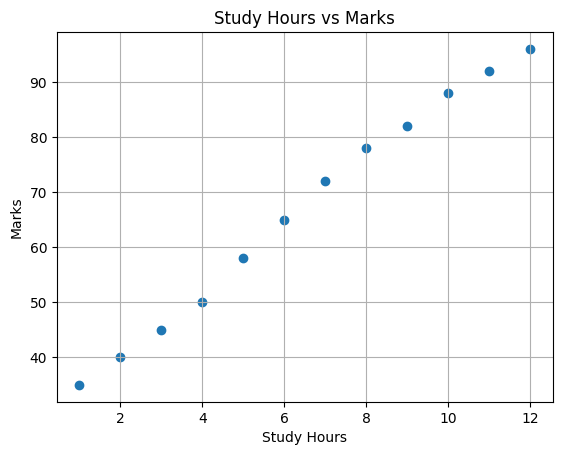

In [37]:
plt.scatter(df["Study_Hours"], df["Marks"])
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

In [38]:
import plotly.express as px
fig = px.scatter(
    df,
    x="Attendance",
    y="Marks",
    hover_data=["Attendance", "Marks"]
)
fig.update_layout(
    title="Attendance vs Marks",
    xaxis_title="Attendance",
    yaxis_title="Marks"
)
fig.show()

In [39]:
fig = px.scatter(
    df,
    x="Assignments",
    y="Marks",
    color="Marks",
    title="Assignments vs Marks"
)
fig.update_layout(
    xaxis_title="Assignments",
    yaxis_title="Marks"
)
fig.show()

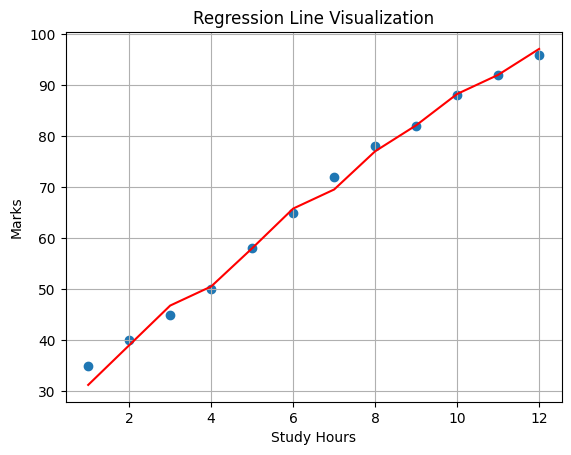

In [40]:
plt.scatter(df["Study_Hours"], df["Marks"])
plt.plot(
    df["Study_Hours"],
    model.predict(X),
    color="red"
)
plt.title("Regression Line Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

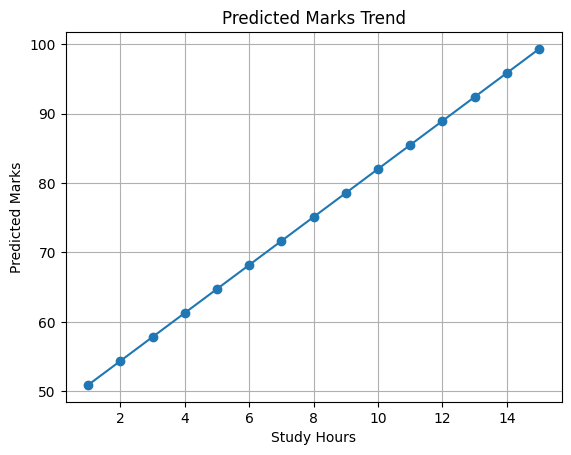

In [43]:
hours = pd.DataFrame({
    "Study_Hours": range(1, 16),
    "Attendance": [80] * 15,
    "Assignments": [5] * 15
})
predicted_marks = model.predict(hours)
plt.plot(hours["Study_Hours"], predicted_marks, marker="o")
plt.title("Predicted Marks Trend")
plt.xlabel("Study Hours")
plt.ylabel("Predicted Marks")
plt.grid(True)
plt.show()